# DK1 Electricity Price Forecasting — Panel VAR (Task 1)

**Econometric Game 2026 — Short-Term Forecasting**

For each forecast horizon h ∈ {1,…,7}, we estimate a **pooled panel OLS** regression
across the 24 hours of the day:

$$p_{t+h,k} = \alpha_k + \sum_{j=0}^{6} \beta_{j,k} \cdot p_{t-j,k} + \gamma \cdot X_t + \text{DOW} + \text{month} + \varepsilon$$

- $\alpha_k$: hour-specific intercept (entity fixed effect)
- $\beta_{j,k}$: hour-specific lag coefficients (via interaction terms)
- $\gamma$: shared exogenous slopes (common across hours)

Forecast origin: **t = 31 Dec 2023**. Model h=1 predicts Jan 1, h=2 predicts Jan 2, …, h=7 predicts Jan 7.
This produces the 7×24 = 168 hourly forecasts required for Task 1.

---
## 0 · Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from linearmodels.panel import PanelOLS

sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 120

DATA = Path('..') / 'data'

# ── Model configuration ──────────────────────────────────────────────────────
N_LAGS   = 7        # daily lags: p_t, p_{t-1}, ..., p_{t-6}
HORIZONS = range(1, 8)  # h = 1, 2, ..., 7

TRAIN_END    = '2023-12-31'
ORIGIN_DATE  = pd.Timestamp('2023-12-31')  # single forecast origin
TEST_START   = '2024-01-01'
TEST_END     = '2024-01-07'

WINSOR_LO = 0.05
WINSOR_HI = 0.95

# Toggleable exogenous variable lists
# Hourly columns: kept at hourly resolution (joined on date + hour)
EXOG_HOURLY = [
    'wind_day_ahead_mw',
    'day_ahead_load_forecast_mw',
    'net_import_de_mw',
    'net_import_dk2_mw'
]

# Already-daily columns: first value per date (broadcast across hours)
EXOG_DAILY = [
    #'gas_price',
    #'eua_price',
]

EXOG_COLS = EXOG_HOURLY + EXOG_DAILY

print(f'Horizons: {list(HORIZONS)}')
print(f'Lags: {N_LAGS} (p_t through p_{{t-{N_LAGS-1}}})')
print(f'Exogenous: {EXOG_COLS}')

Horizons: [1, 2, 3, 4, 5, 6, 7]
Lags: 7 (p_t through p_{t-6})
Exogenous: ['wind_day_ahead_mw', 'day_ahead_load_forecast_mw', 'net_import_de_mw', 'net_import_dk2_mw']


In [2]:
# ── Evaluation helpers ─────────────────────────
def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    mask = np.abs(y_true) > 1.0  # exclude near-zero / negative prices
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(name, y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return pd.Series({
        'MAE':  round(mae(y_true, y_pred), 3),
        'RMSE': round(rmse(y_true, y_pred), 3),
        'MAPE': round(mape(y_true, y_pred), 3),
    }, name=name)

---
## 1 · Load Data

In [3]:
raw = pd.read_csv(
    DATA / 'hourly_features.csv',
    parse_dates=['ts_utc'],
    index_col='ts_utc',
)
raw.index = raw.index.tz_localize('UTC')

# Forward-fill commodity prices (NaN on weekends/holidays)
for col in ['gas_price', 'eua_price', 'coal_price', 'oil_price']:
    if col in raw.columns:
        raw[col] = raw[col].ffill()

# Extract date and hour
raw['date'] = raw.index.normalize().tz_localize(None)
raw['hour'] = raw.index.hour

print(f'Raw data: {raw.shape[0]:,} hourly obs, {raw.index.min().date()} to {raw.index.max().date()}')
print(f'Price NaN: {raw["day_ahead_price_eur_mwh"].isna().sum()}')

Raw data: 61,368 hourly obs, 2018-01-01 to 2024-12-31
Price NaN: 0


---
## 2 · Reshape to Daily Panel

In [4]:
# ── 2a. Pivot prices to daily-wide format (date × 24 hours) ─────────────────
price_wide = raw.pivot_table(
    index='date', columns='hour',
    values='day_ahead_price_eur_mwh', aggfunc='first',
)
price_wide.columns = list(range(24))
print(f'Price wide: {price_wide.shape}  ({price_wide.index.min().date()} to {price_wide.index.max().date()})')

# ── 2b. Build exogenous variables ────────────────────────────────────────────
# Hourly columns: pivot to long format (date, hour) — preserves hourly resolution
exog_hourly_long = raw.set_index(['date', 'hour'])[EXOG_HOURLY].copy()
exog_hourly_long = exog_hourly_long[~exog_hourly_long.index.duplicated(keep='first')]

# ── 2b-ii. Lagged exogenous (lags 1–7 days, hourly resolution) ──────────────
# For each exog variable, pivot to wide (date × 24h), shift by j days,
# stack back to long (date, hour) → column name: {var}_lag{j}
exog_lag_frames = []
for col in EXOG_HOURLY:
    col_wide = raw.pivot_table(index='date', columns='hour', values=col, aggfunc='first')
    col_wide.columns = list(range(24))
    for j in range(1, N_LAGS + 1):
        lagged = col_wide.shift(j).stack()
        lagged.index.names = ['date', 'hour']
        lagged.name = f'{col}_lag{j}'
        exog_lag_frames.append(lagged)

exog_lags_long = pd.concat(exog_lag_frames, axis=1)
EXOG_LAG_COLS = list(exog_lags_long.columns)

print(f'Exog hourly (long): {exog_hourly_long.shape}')
print(f'Exog lags (long):   {exog_lags_long.shape}  ({len(EXOG_HOURLY)} vars × {N_LAGS} lags = {len(EXOG_LAG_COLS)} cols)')

# Daily columns: first value per date (will be broadcast across hours during join)
exog_daily = pd.DataFrame(index=price_wide.index)
for col in EXOG_DAILY:
    exog_daily[col] = raw.groupby('date')[col].first()

print(f'Exog daily: {exog_daily.shape}')

Price wide: (2557, 24)  (2018-01-01 to 2024-12-31)


Exog hourly (long): (61368, 4)
Exog lags (long):   (61368, 28)  (4 vars × 7 lags = 28 cols)
Exog daily: (2557, 0)


In [5]:
# ── 2c. Build lagged price columns ──────────────────────────────────────────
# For each lag j, shift price_wide by j days, then stack to long format.
# After stacking, each row (date, hour_k) gets hour k's own lagged price.

lag_dict = {}
for j in range(N_LAGS):
    lag_dict[f'price_lag{j}'] = price_wide.shift(j).stack()

lags_long = pd.DataFrame(lag_dict)
lags_long.index.names = ['date', 'hour']
print(f'Lags long: {lags_long.shape}')
lags_long.head()

Lags long: (61368, 7)


price_lag0  price_lag1  price_lag2  price_lag3  price_lag4  \
date       hour                                                               
2018-01-01 0          26.43         NaN         NaN         NaN         NaN   
           1          26.10         NaN         NaN         NaN         NaN   
           2          24.70         NaN         NaN         NaN         NaN   
           3          24.74         NaN         NaN         NaN         NaN   
           4          18.01         NaN         NaN         NaN         NaN   

                 price_lag5  price_lag6  
date       hour                          
2018-01-01 0            NaN         NaN  
           1            NaN         NaN  
           2            NaN         NaN  
           3            NaN         NaN  
           4            NaN         NaN

In [6]:
# ── 2d. Assemble full panel ─────────────────────────────────────────────────
panel = lags_long.copy()

# Merge hourly exogenous (join on date + hour — exact match)
panel = panel.join(exog_hourly_long, on=['date', 'hour'])

# Merge lagged exogenous (join on date + hour)
panel = panel.join(exog_lags_long, on=['date', 'hour'])

# Merge daily exogenous (broadcast across all 24 hours via date join)
if len(EXOG_DAILY) > 0:
    panel = panel.join(exog_daily, on='date')

# ── Non-working day dummy: weekend OR holiday ────────────────────────────────
is_weekend = raw.groupby('date')['is_weekend'].first()
is_holiday = raw.groupby('date')['is_holiday'].first()
non_working_daily = ((is_weekend == 1) | (is_holiday == 1)).astype(float)
non_working_daily.name = 'non_working'

panel = panel.join(non_working_daily, on='date')

# Month dummies (drop January=1 as reference)
dates = panel.index.get_level_values('date')
panel['month'] = dates.month

month_dummies = pd.get_dummies(panel['month'], prefix='month', drop_first=True, dtype=float)
month_dummies.index = panel.index

panel = pd.concat([panel.drop(columns=['month']), month_dummies], axis=1)

print(f'Panel shape: {panel.shape}')
print(f'Panel columns ({len(panel.columns)}): {list(panel.columns[:10])} ... {list(panel.columns[-5:])}')

Panel shape: (61368, 51)
Panel columns (51): ['price_lag0', 'price_lag1', 'price_lag2', 'price_lag3', 'price_lag4', 'price_lag5', 'price_lag6', 'wind_day_ahead_mw', 'day_ahead_load_forecast_mw', 'net_import_de_mw'] ... ['month_8', 'month_9', 'month_10', 'month_11', 'month_12']


---
## 3 · Hour-Interacted Lag Features

In [7]:
# For hour-specific slopes on lagged prices, create interaction terms:
# h{k}_lag{j} = I(hour == k) * price_lag{j}
# This gives 24 * 7 = 168 columns. For each row, only 7 are nonzero.

hour_values = panel.index.get_level_values('hour')

interaction_cols = []
for j in range(N_LAGS):
    lag_col = panel[f'price_lag{j}'].values
    for k in range(24):
        col_name = f'h{k}_lag{j}'
        panel[col_name] = np.where(hour_values == k, lag_col, 0.0)
        interaction_cols.append(col_name)

# Drop raw lag columns (fully captured by interactions)
panel.drop(columns=[f'price_lag{j}' for j in range(N_LAGS)], inplace=True)

# Identify column groups
dummy_cols = ['non_working'] + [c for c in panel.columns if c.startswith('month_')]
X_COLS = interaction_cols + EXOG_COLS + EXOG_LAG_COLS + dummy_cols

print(f'Interaction columns: {len(interaction_cols)}')
print(f'Exogenous (t=0):     {len(EXOG_COLS)}')
print(f'Exogenous (lags):    {len(EXOG_LAG_COLS)}')
print(f'Dummy columns:       {len(dummy_cols)}  (non_working + 11 month)')
print(f'Total regressors:    {len(X_COLS)}')

Interaction columns: 168
Exogenous (t=0):     4
Exogenous (lags):    28
Dummy columns:       12  (non_working + 11 month)
Total regressors:    212


---
## 4 · Build Outcome Variables & Winsorise

In [8]:
# For each horizon h, the outcome is price h days ahead at the same hour.
# We pre-compute all outcomes and their winsorisation bounds here.

outcomes = {}       # h -> Series
winsor_bounds = {}  # h -> (lo, hi)

first_valid_date = price_wide.index[N_LAGS - 1]  # need all 7 lags

for h in HORIZONS:
    # Outcome: price h days ahead, stacked to long
    y = price_wide.shift(-h).stack()
    y.index.names = ['date', 'hour']
    y.name = 'price_ahead'
    
    # Training dates: features valid AND outcome within training period
    last_train_date = pd.Timestamp(TRAIN_END) - pd.Timedelta(days=h)
    train_mask = (
        (y.index.get_level_values('date') >= first_valid_date) &
        (y.index.get_level_values('date') <= last_train_date)
    )
    
    # Winsorisation bounds from training data only
    y_train = y[train_mask].dropna()
    lo = y_train.quantile(WINSOR_LO)
    hi = y_train.quantile(WINSOR_HI)
    winsor_bounds[h] = (lo, hi)
    
    # Apply winsorisation
    outcomes[h] = y.clip(lo, hi)
    
    print(f'h={h}: train dates {first_valid_date.date()}..{last_train_date.date()}, '
          f'winsor [{lo:.1f}, {hi:.1f}] EUR/MWh, '
          f'train obs = {train_mask.sum():,}')

h=1: train dates 2018-01-07..2023-12-30, winsor [5.0, 276.3] EUR/MWh, train obs = 52,416
h=2: train dates 2018-01-07..2023-12-29, winsor [5.0, 276.4] EUR/MWh, train obs = 52,392
h=3: train dates 2018-01-07..2023-12-28, winsor [5.0, 276.6] EUR/MWh, train obs = 52,368
h=4: train dates 2018-01-07..2023-12-27, winsor [5.0, 276.9] EUR/MWh, train obs = 52,344
h=5: train dates 2018-01-07..2023-12-26, winsor [5.0, 277.0] EUR/MWh, train obs = 52,320
h=6: train dates 2018-01-07..2023-12-25, winsor [5.0, 277.0] EUR/MWh, train obs = 52,296
h=7: train dates 2018-01-07..2023-12-24, winsor [5.0, 277.4] EUR/MWh, train obs = 52,272


---
## 5 · Fit Panel Models

In [9]:
# Fit one PanelOLS model per horizon h.
# Entity = hour (24 groups), Time = date.
# entity_effects=True provides hour-specific intercepts.
# Hour-specific lag slopes are captured by the interaction columns.

results = {}  # h -> PanelOLS result

for h in HORIZONS:
    y = outcomes[h]
    last_train_date = pd.Timestamp(TRAIN_END) - pd.Timedelta(days=h)
    
    # Valid training observations
    valid_mask = (
        (panel.index.get_level_values('date') >= first_valid_date) &
        (panel.index.get_level_values('date') <= last_train_date)
    )
    
    # Assemble regression data
    reg_X = panel.loc[valid_mask, X_COLS].copy()
    reg_y = y.reindex(reg_X.index)
    
    # Drop rows with any NaN
    valid = reg_y.notna() & reg_X.notna().all(axis=1)
    reg_X = reg_X[valid]
    reg_y = reg_y[valid]
    
    # PanelOLS requires MultiIndex with entity as first level
    # Current index: (date, hour) -> swap to (hour, date)
    reg_X = reg_X.swaplevel().sort_index()
    reg_y = reg_y.swaplevel().sort_index()
    
    mod = PanelOLS(
        dependent=reg_y,
        exog=reg_X,
        entity_effects=True,
    )
    res = mod.fit(cov_type='clustered', cluster_entity=True)
    results[h] = res
    
    print(f'h={h}: {reg_X.shape[0]:,} obs, R² = {res.rsquared:.4f}, '
          f'R²(within) = {res.rsquared_within:.4f}')

print('\nAll 7 models fitted.')

h=1: 51,792 obs, R² = 0.7595, R²(within) = 0.7595


h=2: 51,768 obs, R² = 0.7088, R²(within) = 0.7088


h=3: 51,744 obs, R² = 0.6902, R²(within) = 0.6902


h=4: 51,720 obs, R² = 0.6766, R²(within) = 0.6766


h=5: 51,696 obs, R² = 0.6692, R²(within) = 0.6692


h=6: 51,672 obs, R² = 0.6621, R²(within) = 0.6621


h=7: 51,648 obs, R² = 0.6577, R²(within) = 0.6577

All 7 models fitted.


In [10]:
# Show summary for h=1 model
print(results[1].summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:            price_ahead   R-squared:                        0.7595
Estimator:                   PanelOLS   R-squared (Between):              0.7798
No. Observations:               51792   R-squared (Within):               0.7595
Date:                Thu, Apr 09 2026   R-squared (Overall):              0.7708
Time:                        12:50:32   Log-likelihood                -2.564e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      767.92
Entities:                          24   P-value                           0.0000
Avg Obs:                       2158.0   Distribution:               F(212,51556)
Min Obs:                       2112.0                                           
Max Obs:                       2160.0   F-statistic (robust):         -1.482e+17
                            

---
## 6 · Generate Forecasts for Jan 1–7, 2024

In [11]:
def build_forecast_features(origin_date, price_wide, exog_hourly_long, exog_lags_long,
                            exog_daily, non_working_daily, n_lags,
                            exog_hourly_cols, exog_lag_cols, exog_daily_cols,
                            dummy_cols_ref):
    """Build a 24-row forecast feature DataFrame for a single origin date."""
    rows = []
    
    for k in range(24):
        row = {}
        
        # Hour-interacted lag features
        for j in range(n_lags):
            lag_date = origin_date - pd.Timedelta(days=j)
            price_val = price_wide.loc[lag_date, k] if lag_date in price_wide.index else np.nan
            for kk in range(24):
                col_name = f'h{kk}_lag{j}'
                row[col_name] = price_val if kk == k else 0.0
        
        # Hourly exogenous variables (current day, look up by date + hour)
        for col in exog_hourly_cols:
            key = (origin_date, k)
            if key in exog_hourly_long.index:
                row[col] = exog_hourly_long.loc[key, col]
            else:
                row[col] = np.nan
        
        # Lagged exogenous variables (look up by date + hour)
        for col in exog_lag_cols:
            key = (origin_date, k)
            if key in exog_lags_long.index:
                row[col] = exog_lags_long.loc[key, col]
            else:
                row[col] = np.nan
        
        # Daily exogenous variables (same value for all hours)
        for col in exog_daily_cols:
            row[col] = exog_daily.loc[origin_date, col] if origin_date in exog_daily.index else np.nan
        
        # Non-working day dummy
        row['non_working'] = float(non_working_daily.loc[origin_date]) if origin_date in non_working_daily.index else 0.0
        
        # Month dummies for the origin date
        month = origin_date.month
        for dc in dummy_cols_ref:
            if dc.startswith('month_'):
                ref_val = int(dc.split('_')[1])
                row[dc] = 1.0 if month == ref_val else 0.0
        
        rows.append(row)
    
    df = pd.DataFrame(rows)
    df.index = pd.MultiIndex.from_arrays(
        [list(range(24)), [origin_date] * 24],
        names=['hour', 'date'],
    )
    return df


# Build forecast features for origin = Dec 31, 2023
X_forecast = build_forecast_features(
    origin_date=ORIGIN_DATE,
    price_wide=price_wide,
    exog_hourly_long=exog_hourly_long,
    exog_lags_long=exog_lags_long,
    exog_daily=exog_daily,
    non_working_daily=non_working_daily,
    n_lags=N_LAGS,
    exog_hourly_cols=EXOG_HOURLY,
    exog_lag_cols=EXOG_LAG_COLS,
    exog_daily_cols=EXOG_DAILY,
    dummy_cols_ref=dummy_cols,
)

print(f'Forecast features shape: {X_forecast.shape}')
print(f'Any NaN: {X_forecast.isna().any().any()}')

Forecast features shape: (24, 212)
Any NaN: False


In [12]:
# ── Generate predictions using manual coefficient application ────────────────
# PanelOLS out-of-sample prediction: y_hat = X @ params + hour_fixed_effect

forecast_table = pd.DataFrame(
    index=pd.date_range(TEST_START, TEST_END, freq='D'),
    columns=list(range(24)),
    dtype=float,
)

for h in HORIZONS:
    res = results[h]
    
    # Extract hour fixed effects (average estimated effect per hour)
    entity_effects = res.estimated_effects
    hour_effects = entity_effects.groupby(level='hour').mean().squeeze()
    
    # Manual prediction: X @ beta + alpha_k
    params = res.params
    X_aligned = X_forecast[params.index]  # ensure column order matches
    
    for k in range(24):
        x_k = X_aligned.loc[k].values  # feature vector for hour k
        yhat_k = x_k @ params.values + hour_effects.loc[k]
        forecast_table.iloc[h - 1, k] = yhat_k

forecast_table.index.name = 'date'
forecast_table.columns.name = 'hour'

print('Forecast table (EUR/MWh):')
forecast_table.round(2)

Forecast table (EUR/MWh):


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,54.08,49.02,47.32,43.65,42.00,34.64,39.26,38.87,42.06,37.57,...,36.95,54.66,69.81,75.88,63.11,54.92,46.46,38.01,36.71,29.78
2024-01-02,45.28,42.89,41.53,38.85,41.59,39.94,46.90,51.74,53.62,51.31,...,47.55,66.57,84.61,92.33,80.33,72.65,68.24,61.17,50.08,44.78
2024-01-03,50.42,46.01,41.10,38.46,41.81,44.41,55.54,60.73,62.52,58.91,...,55.76,70.21,87.41,91.91,80.33,75.32,71.50,65.24,58.00,56.72
2024-01-04,56.32,51.02,46.56,44.04,44.61,45.06,58.54,67.62,70.13,63.96,...,66.24,81.12,97.69,98.33,86.17,80.11,75.33,68.71,57.76,53.83
2024-01-05,50.18,46.15,42.64,42.62,45.46,45.92,51.97,60.79,65.96,62.70,...,65.49,82.15,94.91,89.67,75.29,68.43,59.57,49.59,44.80,40.53
2024-01-06,36.22,35.70,31.32,33.12,36.50,38.31,49.36,53.45,58.31,55.44,...,61.79,78.63,91.16,84.87,69.68,60.15,53.41,45.50,37.86,41.72
2024-01-07,31.76,29.38,27.43,25.93,30.89,30.25,41.39,45.39,49.19,45.68,...,58.44,76.14,90.31,81.63,68.72,60.55,53.36,46.07,38.18,40.55


In [13]:
# ── Load actual prices for Jan 1-7, 2024 ────────────────────────────────────
actual_table = price_wide.loc[TEST_START:TEST_END].copy()
actual_table.index = forecast_table.index  # align

print('Actual prices (EUR/MWh):')
actual_table.round(2)

Actual prices (EUR/MWh):


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,28.14,26.66,4.14,-0.03,-0.02,-0.05,-0.02,0.00,0.08,41.34,...,50.61,59.47,64.99,61.74,61.27,59.97,54.92,47.65,35.55,30.59
2024-01-02,20.07,31.03,18.39,11.08,13.78,47.63,58.10,65.67,64.73,68.98,...,79.96,81.46,80.92,74.95,63.18,57.11,46.89,40.00,21.81,1.04
2024-01-03,-0.01,0.00,-0.01,0.00,0.02,1.09,40.59,59.61,60.61,57.00,...,67.18,73.59,82.28,82.97,79.03,73.23,67.41,65.00,58.12,57.30
2024-01-04,50.46,40.00,25.48,35.00,57.73,72.65,85.02,91.47,94.20,91.61,...,98.62,105.73,133.23,144.65,125.00,103.59,100.01,94.86,88.83,86.08
2024-01-05,80.51,77.01,73.21,74.05,76.03,81.00,87.00,89.57,94.93,96.28,...,100.05,102.97,107.38,108.45,103.96,100.09,94.19,94.92,86.80,82.25
2024-01-06,80.20,76.13,73.01,73.01,74.59,75.10,81.39,88.40,92.23,97.30,...,95.09,99.85,104.69,103.84,99.31,92.23,88.00,86.75,80.03,86.15
2024-01-07,82.46,76.92,75.28,73.33,73.78,75.14,78.04,81.79,85.03,87.15,...,88.01,93.42,101.77,104.85,103.55,100.50,93.31,91.17,83.86,87.02


---
## 7 · Evaluation

In [14]:
# ── Overall metrics (all 168 forecasts) ──────────────────────────────────────
all_pred   = forecast_table.values.flatten()
all_actual = actual_table.values.flatten()

overall = evaluate('Panel OLS (all 168h)', all_actual, all_pred)
print('=== Overall Metrics (Task 1: 168 hourly forecasts) ===')
print(overall)
print()

=== Overall Metrics (Task 1: 168 hourly forecasts) ===
MAE     27.056
RMSE    30.572
MAPE    95.059
Name: Panel OLS (all 168h), dtype: float64



In [15]:
# ── Per-day metrics ──────────────────────────────────────────────────────────
day_metrics = []
for i, h in enumerate(HORIZONS):
    day_pred   = forecast_table.iloc[i].values.astype(float)
    day_actual = actual_table.iloc[i].values.astype(float)
    day_metrics.append(evaluate(f'Day {h} (h={h})', day_actual, day_pred))

day_metrics_df = pd.DataFrame(day_metrics)
print('=== Per-Day Metrics ===')
day_metrics_df

=== Per-Day Metrics ===


,MAE,RMSE,MAPE
Day 1 (h=1),19.215,24.492,82.447
Day 2 (h=2),22.341,24.754,233.368
Day 3 (h=3),14.657,22.626,217.198
Day 4 (h=4),26.341,27.935,31.598
Day 5 (h=5),32.443,33.259,36.317
Day 6 (h=6),35.903,36.833,41.404
Day 7 (h=7),38.492,39.685,45.372


In [16]:
# ── Per-hour metrics ─────────────────────────────────────────────────────────
hour_metrics = []
for k in range(24):
    h_pred   = forecast_table[k].values.astype(float)
    h_actual = actual_table[k].values.astype(float)
    hour_metrics.append(evaluate(f'Hour {k:02d}', h_actual, h_pred))

hour_metrics_df = pd.DataFrame(hour_metrics)
print('=== Per-Hour Metrics (averaged over 7 days) ===')
hour_metrics_df

=== Per-Hour Metrics (averaged over 7 days) ===


,MAE,RMSE,MAPE
Hour 00,33.206,36.471,63.894
Hour 01,30.011,33.221,50.769
Hour 02,35.518,36.834,235.675
Hour 03,33.953,35.989,87.636
Hour 04,33.757,35.220,74.799
Hour 05,32.865,34.847,696.723
Hour 06,27.945,29.734,35.639
Hour 07,25.413,28.409,27.554
Hour 08,25.400,28.644,25.885
Hour 09,23.988,28.521,27.679


---
## 8 · Visualization

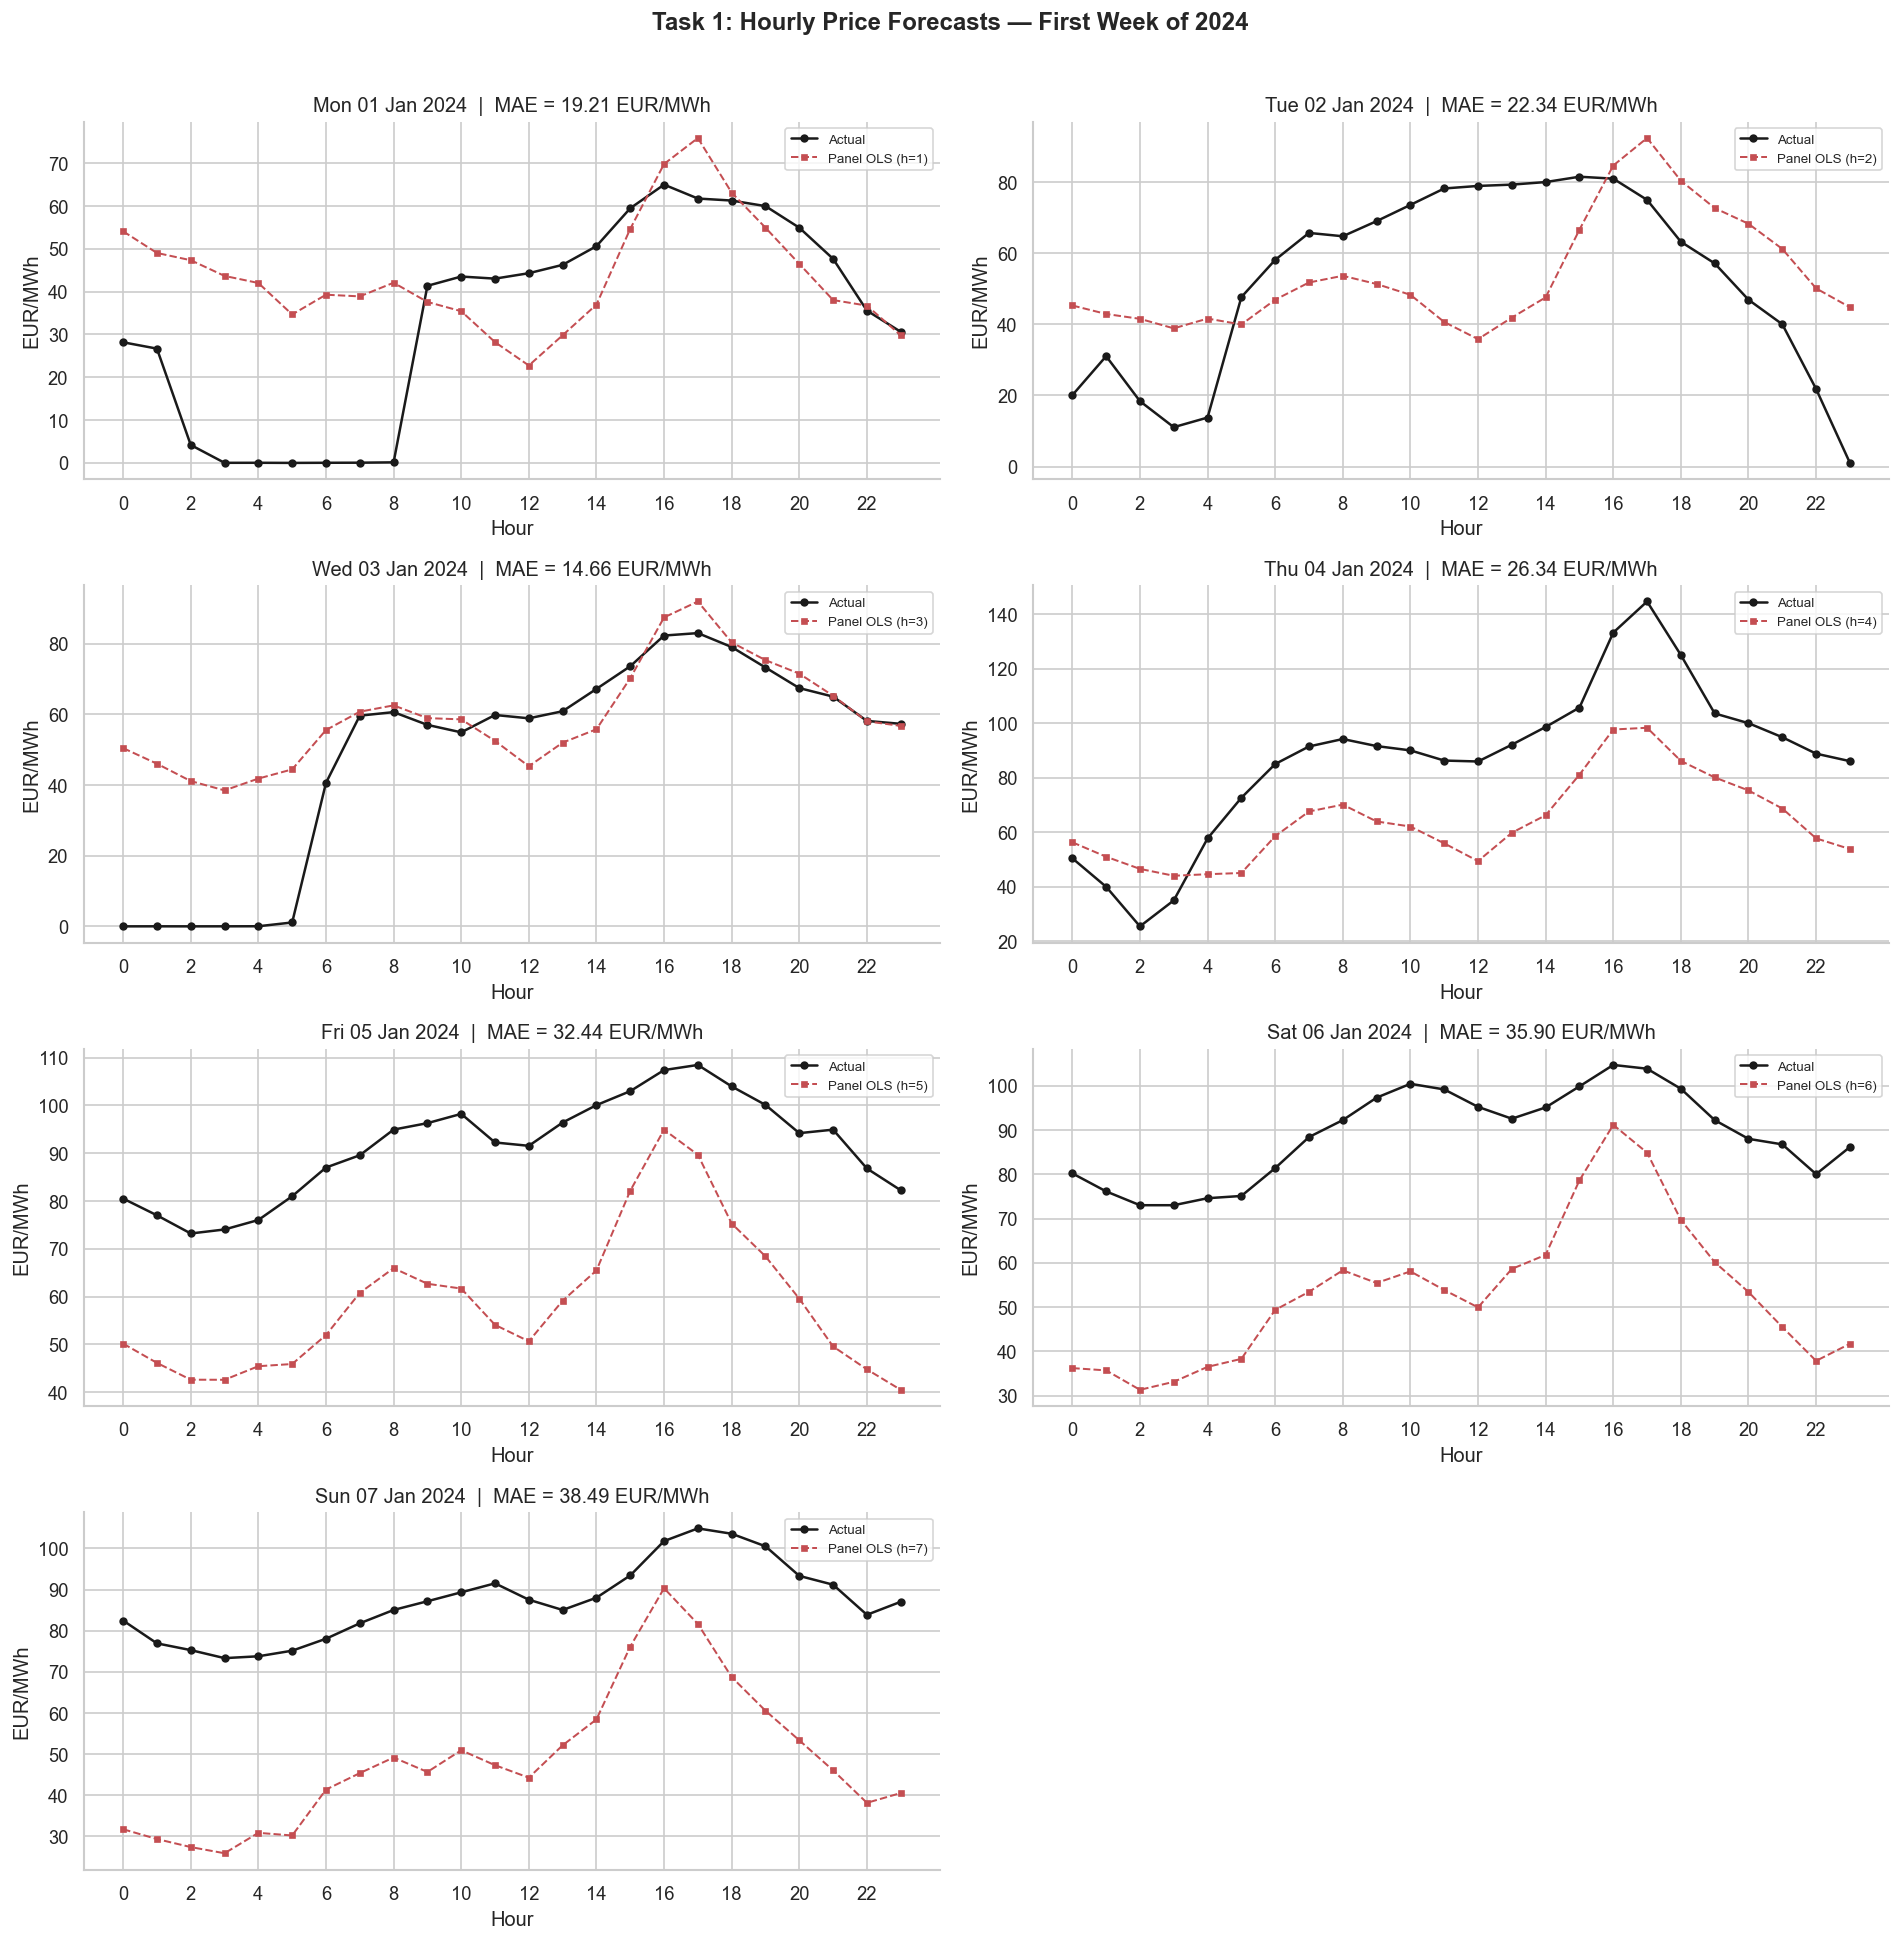

In [17]:
# ── Plot 1: Actual vs Predicted per day ──────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

for i, h in enumerate(HORIZONS):
    ax = axes[i]
    date_label = forecast_table.index[i].strftime('%a %d %b %Y')
    
    actual_vals = actual_table.iloc[i].values.astype(float)
    pred_vals   = forecast_table.iloc[i].values.astype(float)
    
    ax.plot(range(24), actual_vals, 'k-o', ms=4, lw=1.5, label='Actual')
    ax.plot(range(24), pred_vals, 'r--s', ms=3, lw=1.2, label=f'Panel OLS (h={h})')
    
    day_mae = mae(actual_vals, pred_vals)
    ax.set_title(f'{date_label}  |  MAE = {day_mae:.2f} EUR/MWh')
    ax.set_xlabel('Hour')
    ax.set_ylabel('EUR/MWh')
    ax.set_xticks(range(0, 24, 2))
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

# Hide unused subplot
axes[-1].set_visible(False)
fig.suptitle('Task 1: Hourly Price Forecasts — First Week of 2024', fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

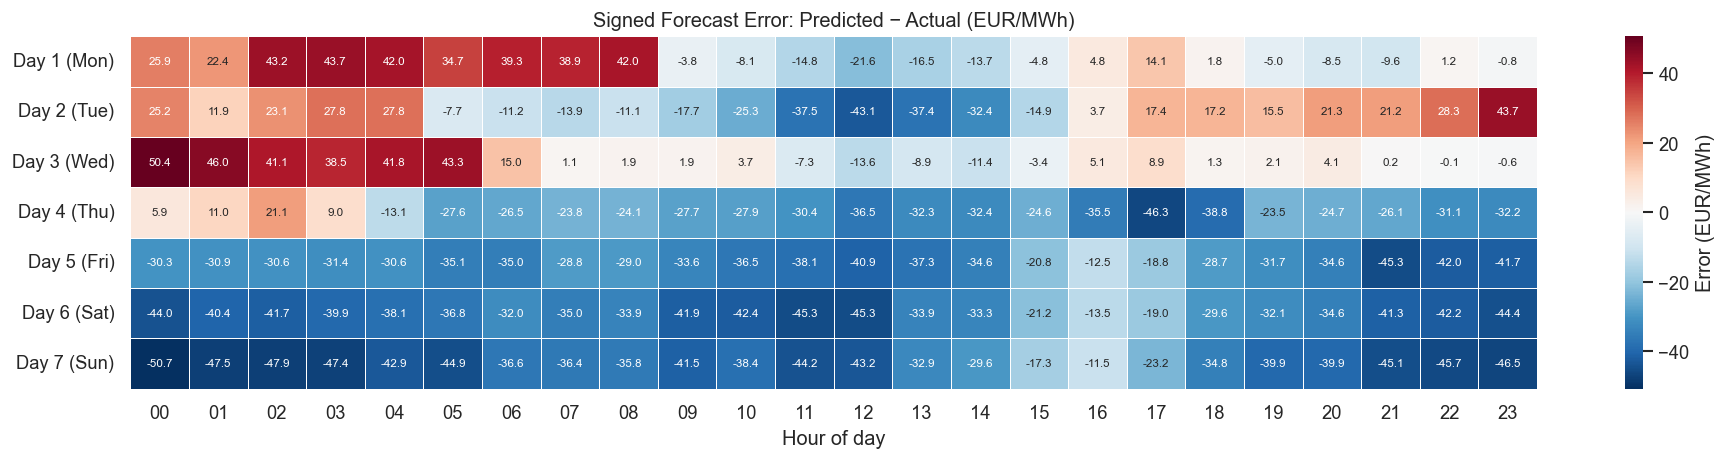

In [18]:
# ── Plot 2: Forecast error heatmap (7 days × 24 hours) ──────────────────────
error_table = forecast_table.values - actual_table.values
error_df = pd.DataFrame(
    error_table,
    index=[f'Day {h} ({forecast_table.index[h-1].strftime("%a")})' for h in HORIZONS],
    columns=[f'{k:02d}' for k in range(24)],
)

fig, ax = plt.subplots(figsize=(16, 4))
vabs = np.abs(error_table).max()
sns.heatmap(
    error_df.astype(float), ax=ax, cmap='RdBu_r', center=0,
    vmin=-vabs, vmax=vabs,
    annot=True, fmt='.1f', annot_kws={'size': 7},
    linewidths=0.3, cbar_kws={'label': 'Error (EUR/MWh)'},
)
ax.set_xlabel('Hour of day')
ax.set_ylabel('')
ax.set_title('Signed Forecast Error: Predicted − Actual (EUR/MWh)')
fig.tight_layout()
plt.show()

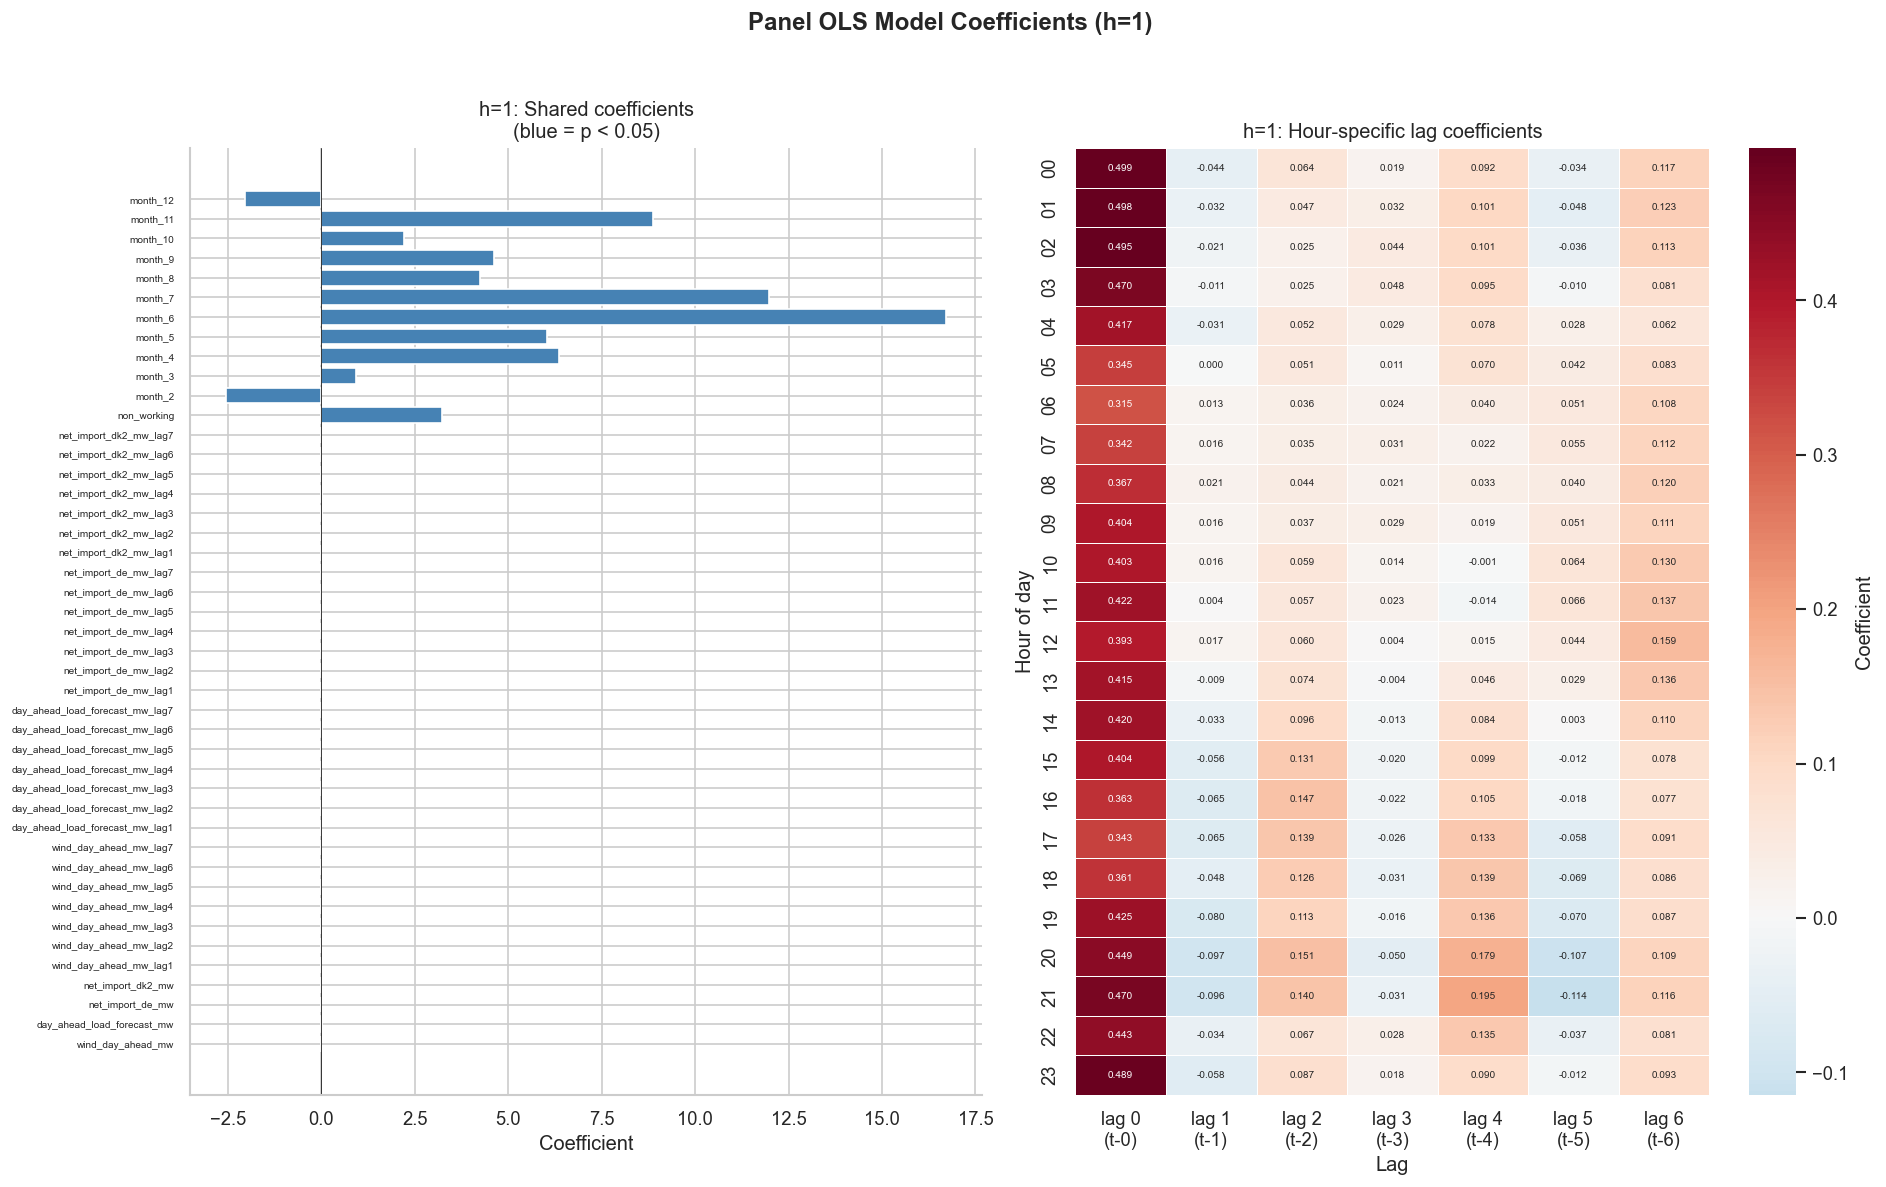

In [19]:
# ── Plot 3: Model coefficients for h=1 ──────────────────────────────────────
res1 = results[1]

# 3a. Exogenous + lagged exog + dummy coefficients (shared across hours)
shared_cols = EXOG_COLS + EXOG_LAG_COLS + dummy_cols
exog_params = res1.params[shared_cols]
sig_mask = res1.pvalues[exog_params.index] < 0.05

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(shared_cols) * 0.22)))

ax = axes[0]
colors = ['steelblue' if s else 'lightgrey' for s in sig_mask]
ax.barh(range(len(exog_params)), exog_params.values, color=colors)
ax.set_yticks(range(len(exog_params)))
ax.set_yticklabels(exog_params.index, fontsize=6)
ax.axvline(0, color='k', lw=0.5)
ax.set_title('h=1: Shared coefficients\n(blue = p < 0.05)')
ax.set_xlabel('Coefficient')
sns.despine(ax=ax)

# 3b. Lag coefficient heatmap (24 hours × 7 lags)
ax = axes[1]
lag_coefs = np.zeros((24, N_LAGS))
for k in range(24):
    for j in range(N_LAGS):
        col_name = f'h{k}_lag{j}'
        if col_name in res1.params.index:
            lag_coefs[k, j] = res1.params[col_name]

sns.heatmap(
    lag_coefs, ax=ax, cmap='RdBu_r', center=0,
    xticklabels=[f'lag {j}\n(t-{j})' for j in range(N_LAGS)],
    yticklabels=[f'{k:02d}' for k in range(24)],
    annot=True, fmt='.3f', annot_kws={'size': 6},
    linewidths=0.3, cbar_kws={'label': 'Coefficient'},
)
ax.set_xlabel('Lag')
ax.set_ylabel('Hour of day')
ax.set_title('h=1: Hour-specific lag coefficients')

fig.suptitle('Panel OLS Model Coefficients (h=1)', fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

---
## 9 · Export

In [20]:
# ── Export forecast table ────────────────────────────────────────────────────
export = forecast_table.copy()
export.columns = [f'hour_{k:02d}' for k in range(24)]
export.to_csv(Path('..') / 'analyses' / 'panel_forecast_task1.csv')

print('Saved: analyses/panel_forecast_task1.csv')
print()

# ── Final summary ────────────────────────────────────────────────────────────
print('=' * 55)
print('  PANEL OLS — Task 1 Summary')
print('=' * 55)
print()
print(f'Forecast origin:  {ORIGIN_DATE.date()}')
print(f'Forecast period:  {TEST_START} to {TEST_END}')
print(f'Total forecasts:  {7 * 24}')
print(f'Winsorisation:    [{WINSOR_LO:.0%}, {WINSOR_HI:.0%}]')
print()
print('Overall:', overall.to_dict())
print()
print('Per-day MAE:')
for i, h in enumerate(HORIZONS):
    print(f'  h={h} ({forecast_table.index[i].strftime("%a %d %b")}): '
          f'{day_metrics_df.iloc[i]["MAE"]:.2f} EUR/MWh')
print()
print('R² (within) by horizon:')
for h in HORIZONS:
    print(f'  h={h}: {results[h].rsquared_within:.4f}')

Saved: analyses/panel_forecast_task1.csv

  PANEL OLS — Task 1 Summary

Forecast origin:  2023-12-31
Forecast period:  2024-01-01 to 2024-01-07
Total forecasts:  168
Winsorisation:    [5%, 95%]

Overall: {'MAE': 27.056, 'RMSE': 30.572, 'MAPE': 95.059}

Per-day MAE:
  h=1 (Mon 01 Jan): 19.21 EUR/MWh
  h=2 (Tue 02 Jan): 22.34 EUR/MWh
  h=3 (Wed 03 Jan): 14.66 EUR/MWh
  h=4 (Thu 04 Jan): 26.34 EUR/MWh
  h=5 (Fri 05 Jan): 32.44 EUR/MWh
  h=6 (Sat 06 Jan): 35.90 EUR/MWh
  h=7 (Sun 07 Jan): 38.49 EUR/MWh

R² (within) by horizon:
  h=1: 0.7595
  h=2: 0.7088
  h=3: 0.6902
  h=4: 0.6766
  h=5: 0.6692
  h=6: 0.6621
  h=7: 0.6577
